# Generate a Parity-check Matrix of an Irregular LDPC Code 

This code is provided as supplementary material of the lecture Channel Coding - Graph-based Codes.

This code illustrates
* get parity-check matrix of an irregular LDPC code specified by degree distribution polynomials using the socket and permutation technique
* Visualization of the parity-check matrix

In [11]:
import numpy as np
from scipy.sparse import coo_matrix
rng = np.random.default_rng()
import matplotlib.pyplot as plt
import cvxpy as cp
print(f"installed solvers:")
print(cp.installed_solvers())


installed solvers:
['CLARABEL', 'HIGHS', 'OSQP', 'SCIP', 'SCIPY', 'SCS']


Helper functions to convert degree distributions from node perspective into edge perspective and vice-versa. For edge perspective, we use polynomials, while for node perspective, we employ a different representation with an array `dv` containing the degrees and the array `a` containing the fraction of nodes of the corresponding degree. For example, the polynomial (from edge perspective) $\lambda(Z) = 0.5 Z^5 + 0.2 Z^2 + 0.3 Z$ is represented by the array `poly = [0.5, 0, 0, 0.2, 0.3, 0]`. It will be transformed into the node-degree polynomial $L(Z) = \frac{1}{2}Z^2 + \frac{2}{9}Z^3 + \frac{5}{18}Z^5$, which is represented by the two arrays `dv = [2,3,6]` and `a = [0.5, 0.2222, 0.2778]` where the numbers correspond to $\frac{1}{2}$, $\frac{2}{9}$, and $\frac{5}{18}$, respectively. This example is shown below.

In [2]:
def edge_to_node(poly):
    """
    converts degree distribution from edge perspective as in density evolution for example
    to distribution from node perspective, 
    """
    int_pol = np.polyint(poly)
    int_pol = int_pol / np.polyval(int_pol, 1)

    idx = np.where(int_pol > 0)[0]
    a = int_pol[idx]
    dv = len(int_pol) - idx - 1

    a = np.flip(a)
    dv = np.flip(dv)

    return dv, a

In [3]:
def node_to_edge(dv, a):
    """
    converts degree distribution from node perspective to distribution from
    edge perspective, as required in density evolution for example
    """
    max_dv = np.max(dv)
    L_poly = np.zeros(shape=(max_dv+1))
    L_poly[max_dv - dv ] = a

    poly = np.polyder(L_poly)
    poly = poly / np.polyval(poly, 1)
    return poly


In [4]:
# Set polynomial shown above
lambda_poly = [0.5, 0, 0, 0.2, 0.3, 0]
print(np.poly1d(lambda_poly, variable='Z'))

# convert to node perspective
dv, a = edge_to_node(lambda_poly)
print(f"dv: {dv}")
print(f"a: {a}")    

# convert back to edge perspective
print("Polynomial converted back to edge perspective:")
poly = node_to_edge(dv, a)
print(np.poly1d(poly, variable='Z'))    

     5       2
0.5 Z + 0.2 Z + 0.3 Z
dv: [2 3 6]
a: [0.5        0.22222222 0.27777778]
Polynomial converted back to edge perspective:
     5       2
0.5 Z + 0.2 Z + 0.3 Z


Helper function to determine the rate from the node degree distributions

In [5]:

def get_rate_LDPC(dv, a_dv, dc, a_dc):
    """
    degree distribution from node perspective
    """
    vn_poly = node_to_edge(dv, a_dv)
    cn_poly = node_to_edge(dc, a_dc)

    return 1 - np.polyval(np.polyint(cn_poly), 1) / np.polyval(np.polyint(vn_poly), 1)


Compute the rate of a code specified by the degree distribution polynomials $\lambda(Z) = 0.409Z + 0.202Z^2+0.0768Z^3+0.1971Z^6+0.1151Z^7$ and $\rho(Z) = Z^5$.

In [6]:
dv, a_dv = edge_to_node( [0.1151, 0.1971, 0, 0, 0.0768, 0.202, 0.409, 0] )
dc, a_dc = edge_to_node( [1, 0, 0, 0, 0, 0] )

print(f"rate: {get_rate_LDPC(dv, a_dv, dc, a_dc)}")

rate: 0.5003666951576612


Function that quantizes the degree distribution such that the edge counts are fulfilled. See lecture for details.

In [7]:
def degdist_to_integer(dv, a_dv, dc, a_dc, N):
    rate = get_rate_LDPC(dv, a_dv, dc, a_dc)
    M = int(round(N*(1 - rate)))

    max_dc = int(np.max(dc))
    max_dv = int(np.max(dv))

    # variables
    num_dc_var_slack = cp.Variable(max_dc)
    num_dv_var_slack = cp.Variable(max_dv)
    num_dc_var = cp.Variable(max_dc, integer=True)
    num_dv_var = cp.Variable(max_dv, integer=True)

    a_dv_temp = np.zeros(shape=max_dv)
    a_dv_temp[dv-1] = a_dv
    dv_temp = np.arange(1, max_dv+1)

    a_dc_temp = np.zeros(shape=max_dc)
    a_dc_temp[dc-1] = a_dc
    dc_temp = np.arange(1, max_dc+1)

    # cost function
    cost = cp.Minimize(cp.sum(num_dv_var_slack) + cp.sum(num_dc_var_slack))

    # constraints
    constraints = []
    constraints += [num_dv_var >= 0, num_dv_var <= N] #upper and lower bound for num_dv_var
    constraints += [num_dc_var >= 0, num_dc_var <= M] #upper and lower bound for num_dc_var
    constraints += [num_dv_var_slack >= 0] #lower bound for num_dv_var_slack
    constraints += [num_dc_var_slack >= 0] #lower bound for num_dc_var_slack
    constraints += [cp.sum(num_dv_var) == N] #sumdv
    constraints += [cp.sum(num_dc_var) == M] #sumdc
    constraints += [dv_temp @ num_dv_var - dc_temp @ num_dc_var == 0] #edges
    constraints += [num_dv_var[1] <= a_dv_temp[1] * N] #nodv2inc
    constraints += [num_dv_var[0] == 0] #nodv1
    constraints += [num_dc_var[0] == 0] #nodc1
    constraints += [num_dc_var[1] == 0] #nodc2
    constraints += [num_dv_var/N - a_dv_temp <= num_dv_var_slack] #slackv1
    constraints += [num_dv_var/N - a_dv_temp >= -num_dv_var_slack] #slackv2
    constraints += [num_dc_var/M - a_dc_temp <= num_dc_var_slack] #slackc1
    constraints += [num_dc_var/M - a_dc_temp >= -num_dc_var_slack] #slackc2

    # solver
    problem = cp.Problem(cost, constraints)
    problem.solve(solver=cp.SCIP)

    if num_dv_var.value is None:
        assert False, "Could not solve optimization problem for finding integer degree distribution"
    
    num_dv = np.round(num_dv_var.value).astype(int)
    new_dv = dv_temp[num_dv != 0]
    num_dv = num_dv[num_dv != 0]

    num_dc = np.round(num_dc_var.value).astype(int)
    new_dc = dc_temp[num_dc != 0]
    num_dc = num_dc[num_dc != 0]

    return new_dv, num_dv, new_dc, num_dc

In [8]:
def getIrregularH(N, lambdA, rho):
    """
    lambda is the degree distribution polynomial from edge perspective and
    the first element is the coefficient corresponding to the largest degree,
    i.e., lambda = [lambda_N, lambda_{N-1}, ..., lambda_2, lambda_1]

    For example, consider
    lambda = [0.5 0 0 0.2 0.3 0]
    This would correspond to a polynomial
                    5        2        
    Lambda(Z) = 0.5 Z  + 0.2 Z  + 0.3 Z

    rho is similarly defined

    For example, to generate the second irregular code example of the lecture
    with n = 10000, we can call
    H = getIrregularH(10000, [0.1151 0.1971 0 0 0.0768 0.202 0.409 0], [1 0 0 0 0 0])

    we can verify that d_{c,avg} = 6 using dcavg = mean(sum(H,2)) and that
    d_{v,avg} = 3 using dvacg = mean(sum(H,1))
    """
    t_dv, t_a_dv = edge_to_node(lambdA)
    t_dc, t_a_dc = edge_to_node(rho)

    dv, n_dv, dc, n_dc = degdist_to_integer(t_dv, t_a_dv, t_dc, t_a_dc, N)

    n_dv = np.round(n_dv).astype(int)
    n_dc = np.round(n_dc).astype(int)

    #E = dv.T @ n_dv

    idx_i = []
    offset = 0
    for k in range(len(dv)):
        temp = np.tile(np.arange(n_dv[k]), dv[k])
        idx_i.append(temp + offset)
        offset += n_dv[k]
    idx_i = np.concatenate(idx_i)

    idx_j = []
    offset = 0
    for k in range(len(dc)):
        temp = np.tile(np.arange(n_dc[k]), dc[k])
        idx_j.append(temp + offset)
        offset += n_dc[k]
    idx_j = np.concatenate(idx_j)

    # find permutation
    permutation = rng.permutation(np.arange(len(idx_j)))

    idx_j = idx_j[permutation]

    abort = False
    while not abort:
        H = coo_matrix((np.ones_like(idx_i), (idx_j, idx_i))).toarray()

        if not np.any(H == 2):
            abort = True
        else:
            # eliminate double edges
            for k in range(N):
                ti = np.where(idx_i == k)[0]

                unique_idx, counts = np.unique(idx_j[ti], return_counts=True)
                duplicates = unique_idx[counts > 1] # duplicates
                if duplicates.size > 0:
                    largeval = duplicates[0]
                    largeidx = np.where(idx_j[ti] == largeval)[0][0]
                    temp = idx_j[ti[largeidx]]
                    rv = rng.integers(idx_j.size)
                    idx_j[ti[largeidx]] = idx_j[rv]
                    idx_j[rv] = temp

    return H

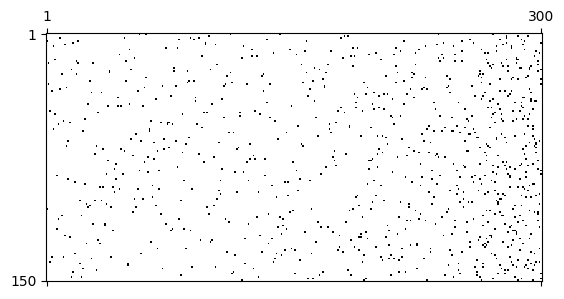

In [12]:
H = getIrregularH(300, [0.1151, 0.1971, 0, 0, 0.0768, 0.202, 0.409, 0], [1, 0, 0, 0, 0, 0])
plt.spy(H)
m, n = H.shape

plt.xticks([0, n-1], [1, n])
plt.yticks([0, m-1], [1, m])
plt.show()

Code to remove 4-cycles

In [14]:
def myrandsample(v, num):
    idx = rng.integers(v.size, size=num)
    return v[idx]

def remove_4cycle(H):
    # removes cycles of length 4
    success = True
    _, N = H.shape

    abort = False
    trials = 0
    while not abort:
        T = H.T @ H - np.diag(np.sum(H, axis=0))
        v1s, v2s = np.where(np.triu(T) >= 2)
        # vs[:,1].size
        if v1s.size == 0: # array is empty
            abort = True
        
        for k in range(v1s.size):
            v1 = v1s[k]
            v2 = v2s[k]

            # common check node
            cncs = np.where(H[:,v1] + H[:,v2] == 2)[0]
            if cncs.size >= 2:
                cn = np.where(H[:,v1] + H[:,v2] == 2)[0][0]
                find_replace = False
                
                while not find_replace:
                    vni = myrandsample(np.setdiff1d(np.arange(N), [v1, v2]), 1)[0]
                    if np.all(H[:,v2] * H[:,vni] == 0):
                        cnt = myrandsample(np.where(H[:,vni])[0], 1)[0]
                        # swap edges
                        temp = H[[cnt, cn], v2]
                        H[[cnt, cn], v2] = H[[cnt, cn], vni]
                        H[[cnt, cn], vni] = temp
                        find_replace = True
        
        trials += 1
        if trials > 500:
            success = False
            abort = True
    
    return H, success


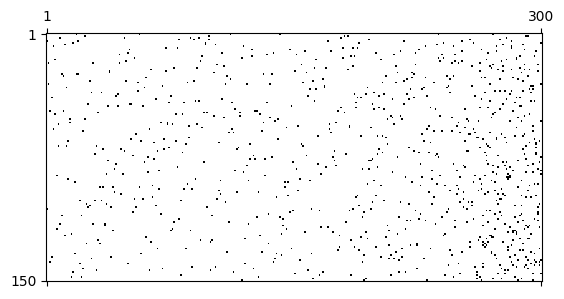

In [20]:
H_no4, success = remove_4cycle(H)
if success:
    plt.spy(H_no4)
    m, n = H_no4.shape

    plt.xticks([0, n-1], [1, n])
    plt.yticks([0, m-1], [1, m])
    plt.show()
else:   
    print("Could not remove all 4-cycles after 500 trials")